# SleepAI Notebook 01 : Exploration des données

**Projet :** Classification automatique des stades de sommeil et détection des apnées  
**Datasets :**
- **Sleep-EDF (PhysioNet)** — Signaux EEG polysomnographiques, 5 stades de sommeil
- **Apnea-ECG (PhysioNet)** — Signaux ECG mono-dérivation, détection apnées minute/minute

**Auteur :** Marine Deldicque  
**Contexte :** AIA Jedha, Bloc 4 : Conception, déploiement et surveillance de solutions d'IA

---

## Plan du notebook

**Partie A Sleep-EDF (EEG + stades de sommeil)**
1. Chargement et inspection des fichiers EDF
2. Visualisation des signaux EEG bruts
3. Distribution des stades de sommeil
4. Analyse spectrale (FFT + bandes de fréquence)
5. Hypnogrammes

**Partie B Apnea-ECG (ECG + détection apnées)**
1. Chargement des fichiers WFDB
2. Visualisation des signaux ECG
3. Distribution apnée / normal
4. Comparaison signal apnée vs normal
5. Analyse de l'AHI par sujet

## 0. Imports et configuration

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Librairies EEG/ECG
import mne
import wfdb
from scipy import signal as scipy_signal
from scipy.signal import welch

# Configuration graphique
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
PALETTE = ['#2E4057', '#048A81', '#54C6EB', '#EF8354', '#E84855']
sns.set_palette(PALETTE)

# Chemins des données
DATA_RAW_EEG  = Path('../data/raw')         # Fichiers Sleep-EDF .edf
DATA_RAW_ECG  = Path('../data/raw_apnea')   # Fichiers Apnea-ECG .dat/.hea/.apn

print('Imports OK')
print(f'EEG data : {DATA_RAW_EEG.resolve()}')
print(f'ECG data : {DATA_RAW_ECG.resolve()}')

Imports OK
EEG data : /Users/marinedeldicque/Library/Mobile Documents/com~apple~CloudDocs/JEDHA/DATA SCIENCE LEAD/aia/bloc 4 projet final/sleepai/data/raw
ECG data : /Users/marinedeldicque/Library/Mobile Documents/com~apple~CloudDocs/JEDHA/DATA SCIENCE LEAD/aia/bloc 4 projet final/sleepai/data/raw_apnea


---
# PARTIE A Sleep-EDF : Stades de sommeil (EEG)

Le dataset **Sleep-EDF Expanded** (PhysioNet) contient des enregistrements polysomnographiques complets de nuit. Chaque sujet a deux fichiers :
- `SC4xxxE0-PSG.edf` : signal EEG brut (+ autres canaux)
- `SC4xxxE*-Hypnogram.edf` : annotations des stades de sommeil

**5 stades annotés :** Wake (W), N1, N2, N3 (sommeil profond), REM

### A1. Chargement et inspection des fichiers EDF

In [34]:
# Lister les fichiers disponibles
psg_files  = sorted(DATA_RAW_EEG.glob('*PSG.edf'))
hyp_files  = sorted(DATA_RAW_EEG.glob('*Hypnogram.edf'))

print(f'Fichiers PSG trouvés     : {len(psg_files)}')
print(f'Fichiers Hypnogram trouvés: {len(hyp_files)}')
print()
print('Premiers fichiers PSG :')
for f in psg_files[:5]:
    print(f'   {f.name}')

Fichiers PSG trouvés     : 30
Fichiers Hypnogram trouvés: 28

Premiers fichiers PSG :
   SC4001E0-PSG.edf
   SC4002E0-PSG.edf
   SC4011E0-PSG.edf
   SC4012E0-PSG.edf
   SC4021E0-PSG.edf


In [35]:
# Charger le premier enregistrement pour inspection
raw = mne.io.read_raw_edf(psg_files[0], preload=True, verbose=False)

print('=== Informations sur l\'enregistrement ===')
print(f'Sujet          : {psg_files[0].name}')
print(f'Canaux         : {raw.ch_names}')
print(f'Fréq. échant.  : {raw.info["sfreq"]} Hz')
print(f'Durée          : {raw.times[-1]/3600:.2f} heures')
print(f'N° échantillons: {len(raw.times):,}')

=== Informations sur l'enregistrement ===
Sujet          : SC4001E0-PSG.edf
Canaux         : ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']
Fréq. échant.  : 100.0 Hz
Durée          : 22.08 heures
N° échantillons: 7,950,000


In [36]:
# Charger les annotations (hypnogramme)
# Mapping stades Sleep-EDF → labels
STAGE_MAPPING = {
    'Sleep stage W' : 0,  # Wake
    'Sleep stage 1' : 1,  # N1
    'Sleep stage 2' : 2,  # N2
    'Sleep stage 3' : 3,  # N3
    'Sleep stage 4' : 3,  # N3 (stade 4 = N3 dans AASM moderne)
    'Sleep stage R' : 4,  # REM
    'Movement time' : 0,  # Traité comme Wake
    # 'Sleep stage ?' → absent du mapping = ignoré automatiquement
}
STAGE_NAMES = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}
STAGE_COLORS = {0: '#E84855', 1: '#EF8354', 2: '#54C6EB', 3: '#048A81', 4: '#2E4057'}

annot = mne.read_annotations(hyp_files[0])
print(f'Nombre d\'annotations : {len(annot)}')
print(f'Descriptions uniques  : {set(annot.description)}')

Nombre d'annotations : 154
Descriptions uniques  : {np.str_('Sleep stage 2'), np.str_('Sleep stage 1'), np.str_('Sleep stage 3'), np.str_('Sleep stage W'), np.str_('Sleep stage 4'), np.str_('Sleep stage R'), np.str_('Sleep stage ?')}


### A2. Visualisation des signaux EEG bruts

Canal EEG utilisé : EEG Fpz-Cz
Fréquence         : 100 Hz
Total échantillons: 7,950,000


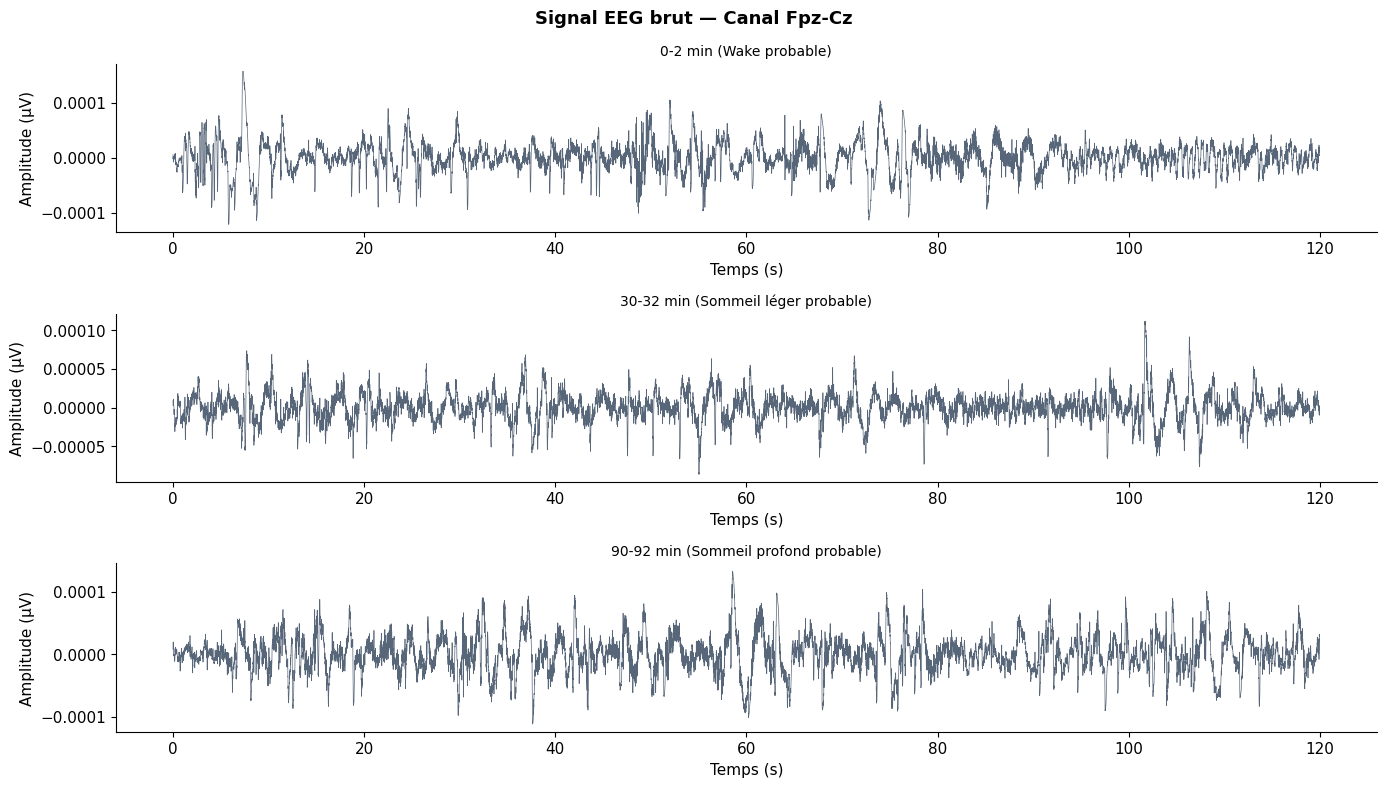

Figure sauvegardée


In [37]:
# Extraire le canal EEG Fpz-Cz (canal principal utilisé pour la classification)
eeg_channel = 'EEG Fpz-Cz' if 'EEG Fpz-Cz' in raw.ch_names else raw.ch_names[0]
data, times = raw[eeg_channel]
data = data[0]  # shape (n_samples,)
fs = int(raw.info['sfreq'])

print(f'Canal EEG utilisé : {eeg_channel}')
print(f'Fréquence         : {fs} Hz')
print(f'Total échantillons: {len(data):,}')

# Visualiser 5 minutes de signal brut
fig, axes = plt.subplots(3, 1, figsize=(14, 8))
fig.suptitle('Signal EEG brut — Canal Fpz-Cz', fontsize=13, fontweight='bold')

segments = [
    (0,         '0-2 min (Wake probable)'),
    (60*30,     '30-32 min (Sommeil léger probable)'),
    (60*90,     '90-92 min (Sommeil profond probable)'),
]

for ax, (start_s, label) in zip(axes, segments):
    start = start_s * fs
    end   = start + 2 * 60 * fs  # 2 minutes
    t = np.arange(end - start) / fs
    ax.plot(t, data[start:end], color='#2E4057', linewidth=0.5, alpha=0.8)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Temps (s)')
    ax.set_ylabel('Amplitude (µV)')

plt.tight_layout()
plt.savefig('../data/figures/eeg_raw_signal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée')

### A3. Distribution des stades de sommeil

In [38]:
# Extraire les stades depuis les annotations
def get_stages_from_annotations(annot_file, duration_per_epoch=30):
    """Extrait les stades de sommeil depuis un fichier hypnogramme."""
    annot = mne.read_annotations(annot_file)
    stages = []
    for a in annot:
        desc = a['description']
        if desc in STAGE_MAPPING:
            n_epochs = int(round(a['duration'] / duration_per_epoch))
            stages.extend([STAGE_MAPPING[desc]] * n_epochs)
    return stages

# Collecter les stades pour tous les sujets
all_stages = []
subject_stats = []

for hyp_f in hyp_files:
    stages = get_stages_from_annotations(hyp_f)
    all_stages.extend(stages)
    counts = pd.Series(stages).value_counts().to_dict()
    subject_stats.append({
        'subject': hyp_f.name[:7],
        'total_epochs': len(stages),
        **{STAGE_NAMES[k]: counts.get(k, 0) for k in range(5)}
    })

df_stats = pd.DataFrame(subject_stats)
print(f'Total époques : {len(all_stages):,}')
print(f'Sujets        : {len(hyp_files)}')
print()
print(df_stats.set_index('subject').head(10))

Total époques : 76,447
Sujets        : 28

         total_epochs  Wake   N1   N2   N3  REM
subject                                        
SC4001E          2650  1997   58  250  220  125
SC4002E          2830  1886   59  373  297  215
SC4011E          2802  1856  109  562  105  170
SC4012E          2848  1824   92  660   96  176
SC4021E          2804  1907   94  545   95  163
SC4022E          2756  1872  184  402  119  179
SC4031E          2820  2008   61  485   57  209
SC4041E          2570  1535  166  620   53  196
SC4042E          2792  1777  137  514   94  270
SC4051E          2722  2258   44  217  135   68


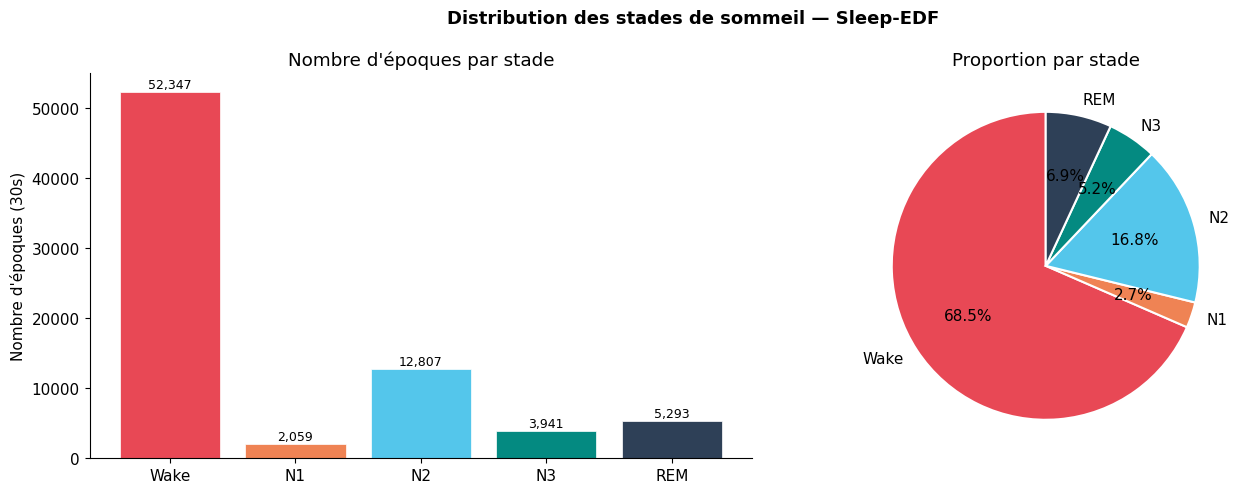


Distribution :
   Wake  : 52,347 époques (68.5%)
   N1    : 2,059 époques (2.7%)
   N2    : 12,807 époques (16.8%)
   N3    : 3,941 époques (5.2%)
   REM   : 5,293 époques (6.9%)

Déséquilibre des classes : à corriger dans le preprocessing (SMOTE ou class_weight)


In [39]:
# Distribution globale des stades
all_stages_series = pd.Series(all_stages)
stage_counts = all_stages_series.value_counts().sort_index()
stage_pct    = stage_counts / stage_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution des stades de sommeil — Sleep-EDF', fontsize=13, fontweight='bold')

# Barplot
colors = [STAGE_COLORS[i] for i in stage_counts.index]
bars = axes[0].bar([STAGE_NAMES[i] for i in stage_counts.index],
                    stage_counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Nombre d\'époques par stade')
axes[0].set_ylabel('Nombre d\'époques (30s)')
for bar, count in zip(bars, stage_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}', ha='center', va='bottom', fontsize=9)

# Pie chart
axes[1].pie(stage_pct.values, labels=[STAGE_NAMES[i] for i in stage_pct.index],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proportion par stade')

plt.tight_layout()
plt.savefig('../data/figures/stage_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDistribution :')
for idx in stage_counts.index:
    print(f'   {STAGE_NAMES[idx]:5s} : {stage_counts[idx]:5,} époques ({stage_pct[idx]:.1f}%)')

print('\nDéséquilibre des classes : à corriger dans le preprocessing (SMOTE ou class_weight)')

### A4. Analyse spectrale : Bandes de fréquence EEG

In [40]:
# Extraire des époques EEG par stade pour l'analyse spectrale
def load_epochs_by_stage(psg_file, hyp_file, n_per_stage=20, fs=100, epoch_len=30):
    """Charge quelques époques EEG par stade de sommeil."""
    raw = mne.io.read_raw_edf(psg_file, preload=True, verbose=False)
    channel = 'EEG Fpz-Cz' if 'EEG Fpz-Cz' in raw.ch_names else raw.ch_names[0]
    data, _ = raw[channel]
    data = data[0]
    
    annot = mne.read_annotations(hyp_file)
    epochs_by_stage = {s: [] for s in range(5)}
    
    for a in annot:
        desc = a['description']
        if desc not in STAGE_MAPPING:
            continue
        stage = STAGE_MAPPING[desc]
        if len(epochs_by_stage[stage]) >= n_per_stage:
            continue
        onset_s = int(a['onset'] * fs)
        end_s   = onset_s + epoch_len * fs
        if end_s <= len(data):
            epochs_by_stage[stage].append(data[onset_s:end_s])
    
    return epochs_by_stage

epochs_by_stage = load_epochs_by_stage(psg_files[0], hyp_files[0])
print('Époques chargées par stade :')
for s, epochs in epochs_by_stage.items():
    print(f'   {STAGE_NAMES[s]:5s} : {len(epochs)} époques')

Époques chargées par stade :
   Wake  : 12 époques
   N1    : 20 époques
   N2    : 20 époques
   N3    : 20 époques
   REM   : 6 époques


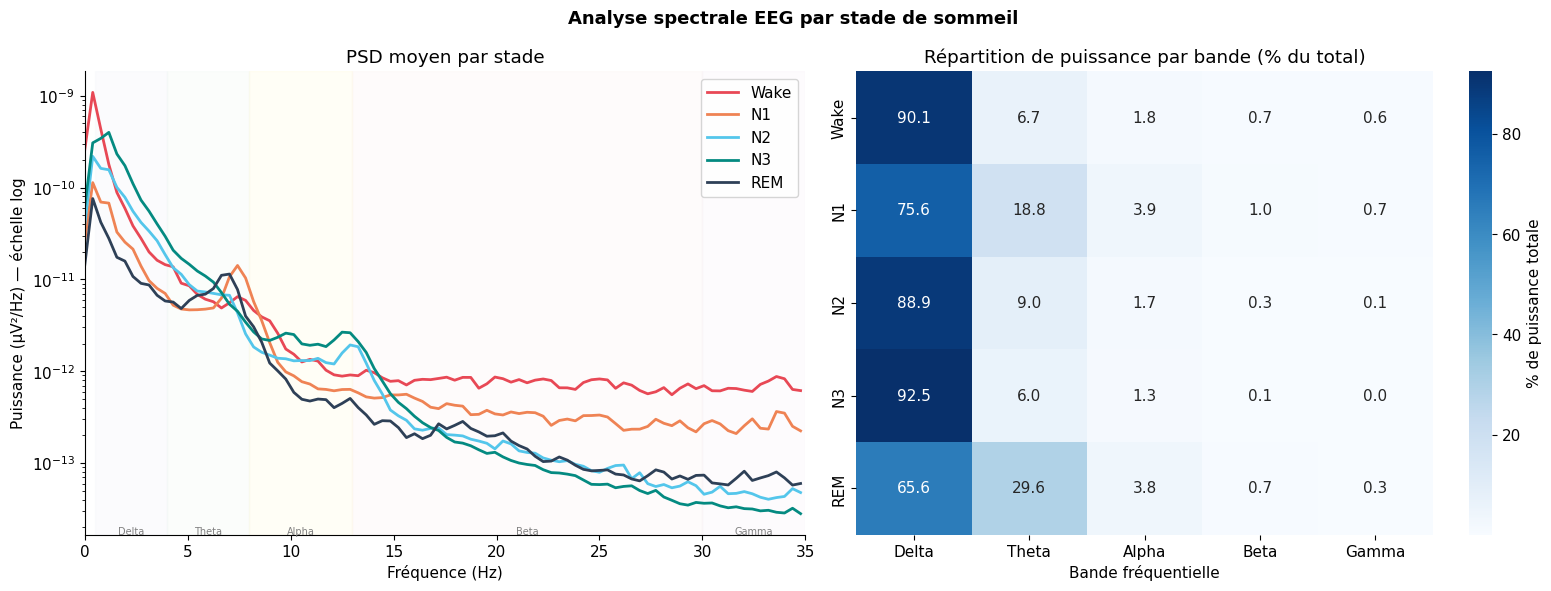


 Lecture :
   N3 (sommeil profond) : forte puissance Delta → ondes lentes
   REM                  : ressemble à Wake mais avec moins de Beta
   N1                   : forte puissance Theta → somnolence


In [41]:
# Densité Spectrale de Puissance (PSD) par stade
FS = 100
BANDS = {
    'Delta\n(0.5-4 Hz)'  : (0.5, 4),
    'Theta\n(4-8 Hz)'    : (4, 8),
    'Alpha\n(8-13 Hz)'   : (8, 13),
    'Beta\n(13-30 Hz)'   : (13, 30),
    'Gamma\n(30-35 Hz)'  : (30, 35),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analyse spectrale EEG par stade de sommeil', fontsize=13, fontweight='bold')

# PSD moyen par stade
for stage_idx, epochs in epochs_by_stage.items():
    if len(epochs) == 0:
        continue
    psds = []
    for epoch in epochs:
        freqs, psd = welch(epoch, fs=FS, nperseg=256)
        psds.append(psd)
    psd_mean = np.mean(psds, axis=0)
    mask = freqs <= 35
    axes[0].semilogy(freqs[mask], psd_mean[mask],
                      color=STAGE_COLORS[stage_idx],
                      label=STAGE_NAMES[stage_idx], linewidth=2)

# Zones de fréquence
band_colors = ['#E8EAF6', '#E8F5E9', '#FFF9C4', '#FBE9E7', '#F3E5F5']
for (label, (fmin, fmax)), bc in zip(BANDS.items(), band_colors):
    axes[0].axvspan(fmin, fmax, alpha=0.15, color=bc)
    axes[0].text((fmin+fmax)/2, axes[0].get_ylim()[0] if axes[0].get_ylim()[0] > 0 else 1e-15,
                  label.split('\n')[0], ha='center', fontsize=7, color='gray')

axes[0].set_xlabel('Fréquence (Hz)')
axes[0].set_ylabel('Puissance (µV²/Hz) — échelle log')
axes[0].set_title('PSD moyen par stade')
axes[0].legend(loc='upper right')
axes[0].set_xlim(0, 35)

# Puissance par bande et par stade (heatmap)
band_powers = {}
for stage_idx, epochs in epochs_by_stage.items():
    if len(epochs) == 0:
        continue
    powers = []
    for epoch in epochs:
        freqs, psd = welch(epoch, fs=FS, nperseg=256)
        row = []
        for _, (fmin, fmax) in BANDS.items():
            mask = (freqs >= fmin) & (freqs < fmax)
            row.append(np.mean(psd[mask]))
        powers.append(row)
    band_powers[STAGE_NAMES[stage_idx]] = np.mean(powers, axis=0)

df_heatmap = pd.DataFrame(band_powers, index=[k.split('\n')[0] for k in BANDS.keys()]).T
# Normaliser par ligne pour comparer les profils
df_heatmap_norm = df_heatmap.div(df_heatmap.sum(axis=1), axis=0) * 100

sns.heatmap(df_heatmap_norm, annot=True, fmt='.1f', cmap='Blues',
            ax=axes[1], cbar_kws={'label': '% de puissance totale'})
axes[1].set_title('Répartition de puissance par bande (% du total)')
axes[1].set_xlabel('Bande fréquentielle')

plt.tight_layout()
plt.savefig('../data/figures/eeg_spectral_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Lecture :')
print('   N3 (sommeil profond) : forte puissance Delta → ondes lentes')
print('   REM                  : ressemble à Wake mais avec moins de Beta')
print('   N1                   : forte puissance Theta → somnolence')

### A5. Hypnogramme : Architecture du sommeil

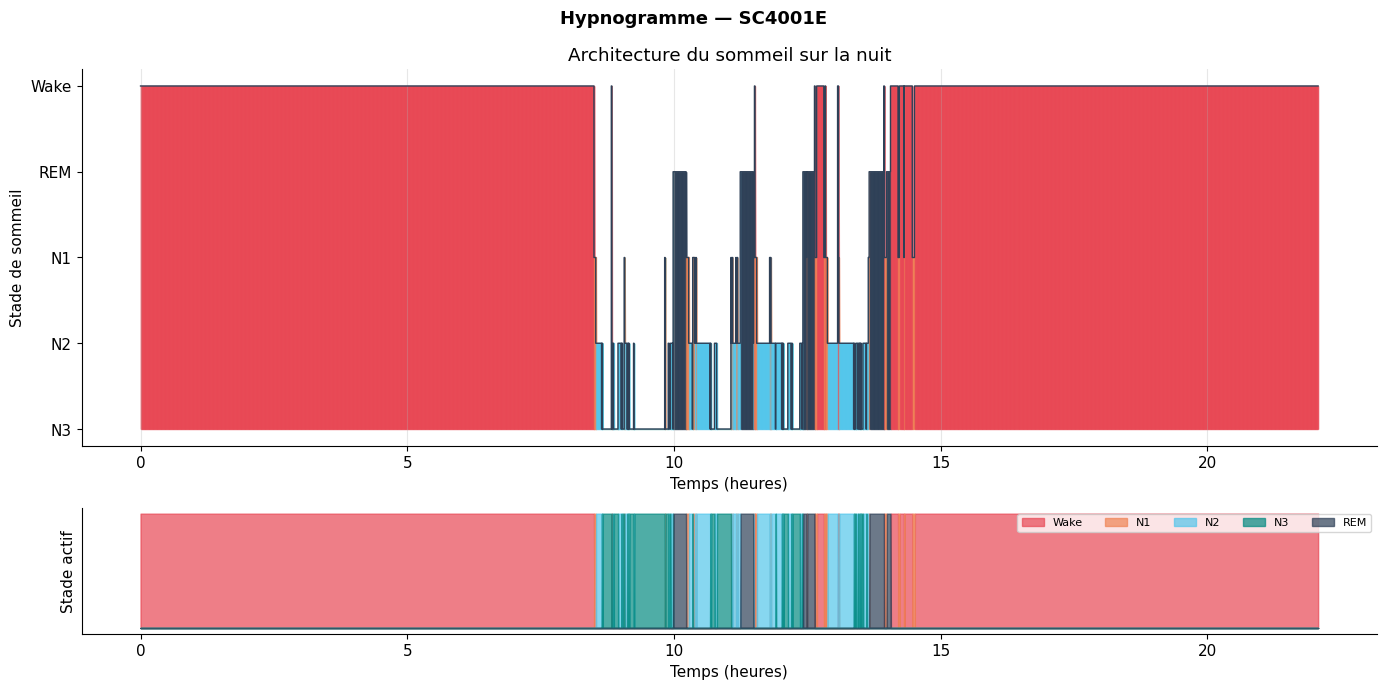


 Architecture typique du sommeil :
   Début de nuit : cycles N2 → N3 dominants (récupération physique)
   Fin de nuit   : cycles REM plus longs (récupération cognitive)


In [42]:
# Tracer l'hypnogramme pour un sujet
stages_subject = get_stages_from_annotations(hyp_files[0])
times_hours = np.arange(len(stages_subject)) * 30 / 3600  # Conversion en heures

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7),
                                 gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle(f'Hypnogramme — {psg_files[0].name[:7]}', fontsize=13, fontweight='bold')

# Hypnogramme classique
stage_to_y = {0: 4, 4: 3, 1: 2, 2: 1, 3: 0}  # Wake en haut, N3 en bas
y_vals = [stage_to_y[s] for s in stages_subject]

# Colorier par stade
for i in range(len(stages_subject) - 1):
    ax1.fill_between([times_hours[i], times_hours[i+1]],
                      [y_vals[i], y_vals[i+1]], [0, 0],
                      color=STAGE_COLORS[stages_subject[i]], alpha=0.6)

ax1.step(times_hours, y_vals, color='#2E4057', linewidth=1)
ax1.set_yticks([0, 1, 2, 3, 4])
ax1.set_yticklabels(['N3', 'N2', 'N1', 'REM', 'Wake'])
ax1.set_xlabel('Temps (heures)')
ax1.set_ylabel('Stade de sommeil')
ax1.set_title('Architecture du sommeil sur la nuit')
ax1.grid(axis='x', alpha=0.3)

# Distribution temporelle des stades
for stage in range(5):
    mask = np.array(stages_subject) == stage
    ax2.fill_between(times_hours, mask.astype(int),
                      color=STAGE_COLORS[stage], alpha=0.7,
                      label=STAGE_NAMES[stage])

ax2.set_xlabel('Temps (heures)')
ax2.set_ylabel('Stade actif')
ax2.legend(loc='upper right', ncol=5, fontsize=8)
ax2.set_yticks([])

plt.tight_layout()
plt.savefig('../data/figures/hypnogram.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Architecture typique du sommeil :')
print('   Début de nuit : cycles N2 → N3 dominants (récupération physique)')
print('   Fin de nuit   : cycles REM plus longs (récupération cognitive)')

---
# PARTIE B / Apnea-ECG : Détection des apnées (ECG)

Le dataset **Apnea-ECG** (PhysioNet) contient 35 enregistrements ECG mono-dérivation de nuit complète avec annotations expert minute par minute :
- `A` (Apnea) : présence d'apnée dans la minute
- `N` (Normal) : respiration normale

**Sujets disponibles :**
- `a01`–`a05` : apnée sévère (AHI ≥ 10, ≥ 100 segments apnée)
- `b01`–`b02` : cas limites (AHI entre 5 et 10)
- `c01`–`c03` : contrôles normaux (AHI < 5)

### B1. Chargement des fichiers WFDB

In [43]:
# Lister les enregistrements disponibles
dat_files = sorted(DATA_RAW_ECG.glob('*.dat'))
subjects  = [f.stem for f in dat_files]

print(f'Enregistrements ECG trouvés : {len(subjects)}')
print(f'Sujets : {subjects}')
print()

# Charger le premier enregistrement
record = wfdb.rdrecord(str(DATA_RAW_ECG / subjects[0]))
annot  = wfdb.rdann(str(DATA_RAW_ECG / subjects[0]), 'apn')

ecg_signal = record.p_signal[:, 0]  # Signal ECG (1 canal)
fs_ecg     = record.fs

print(f'=== Sujet {subjects[0]} ===')
print(f'Fréquence échantillonnage : {fs_ecg} Hz')
print(f'Durée totale              : {len(ecg_signal) / fs_ecg / 3600:.2f} heures')
print(f'N° échantillons           : {len(ecg_signal):,}')
print(f'Annotations apnée         : {len(annot.symbol)} minutes annotées')
print(f'Labels uniques            : {set(annot.symbol)}')

Enregistrements ECG trouvés : 31
Sujets : ['a01', 'a02', 'a03', 'a04', 'a05', 'a06', 'a07', 'a08', 'a09', 'a10', 'a11', 'a12', 'a13', 'a14', 'a15', 'a16', 'a17', 'a18', 'b01', 'b02', 'b03', 'b04', 'b05', 'c01', 'c02', 'c03', 'c04', 'c05', 'c06', 'c08', 'c10']

=== Sujet a01 ===
Fréquence échantillonnage : 100 Hz
Durée totale              : 8.21 heures
N° échantillons           : 2,957,000
Annotations apnée         : 489 minutes annotées
Labels uniques            : {'A', 'N'}


### B2. Visualisation des signaux ECG

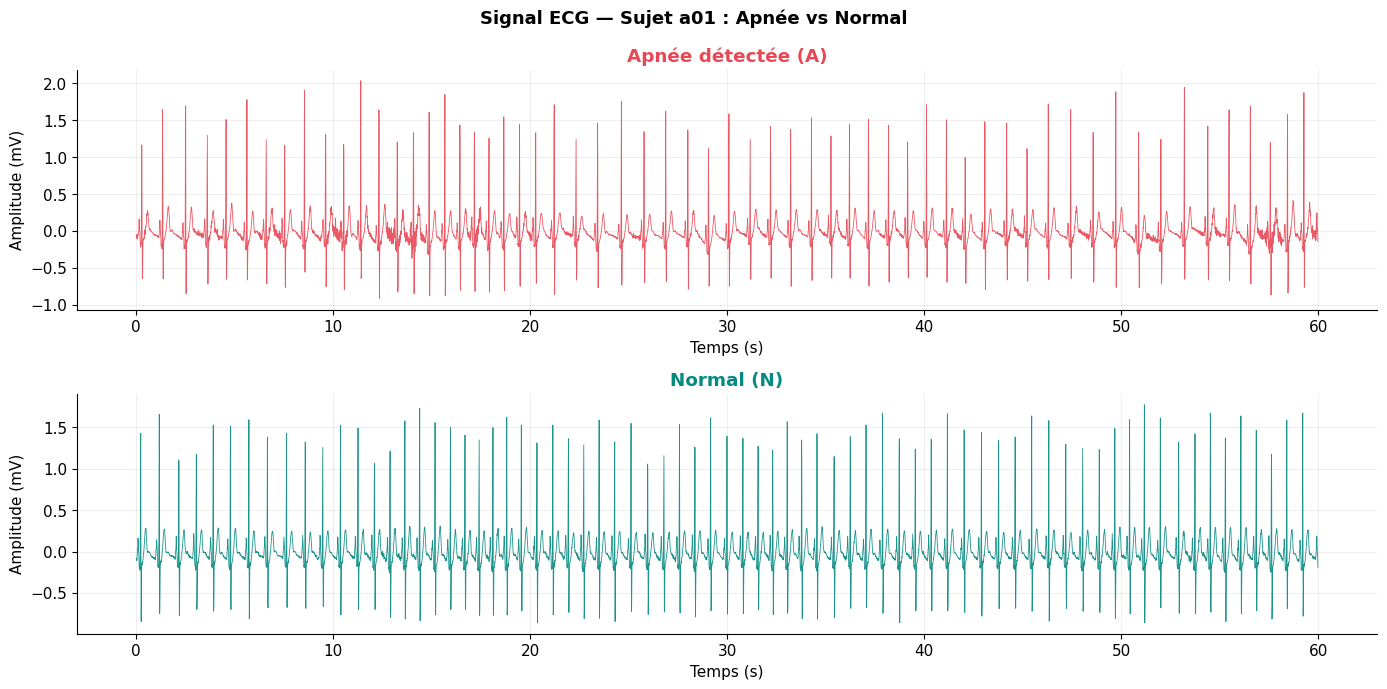


 Observation visuelle :
   Apnée  → irrégularité du rythme cardiaque, variation amplitude
   Normal → rythme sinusal régulier, complexes QRS bien définis


In [44]:
# Visualiser le signal ECG brut — apnée vs normal
SEGMENT_LEN = 60 * fs_ecg  # 1 minute en échantillons

# Trouver une minute avec apnée et une sans
apnea_indices  = [i for i, s in enumerate(annot.symbol) if s == 'A']
normal_indices = [i for i, s in enumerate(annot.symbol) if s == 'N']

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle(f'Signal ECG — Sujet {subjects[0]} : Apnée vs Normal', fontsize=13, fontweight='bold')

for ax, (indices, label, color) in zip(axes, [
    (apnea_indices,  'Apnée détectée (A)', '#E84855'),
    (normal_indices, 'Normal (N)',          '#048A81'),
]):
    if len(indices) == 0:
        ax.text(0.5, 0.5, 'Pas de segment disponible', transform=ax.transAxes, ha='center')
        continue
    
    # Prendre un segment du milieu de la nuit
    mid_idx  = indices[len(indices)//2]
    start    = annot.sample[mid_idx] if mid_idx < len(annot.sample) else mid_idx * SEGMENT_LEN
    end      = min(start + SEGMENT_LEN, len(ecg_signal))
    t        = np.arange(end - start) / fs_ecg
    
    ax.plot(t, ecg_signal[start:end], color=color, linewidth=0.6, alpha=0.9)
    ax.set_title(label, color=color, fontweight='bold')
    ax.set_xlabel('Temps (s)')
    ax.set_ylabel('Amplitude (mV)')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('../data/figures/ecg_apnea_vs_normal.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Observation visuelle :')
print('   Apnée  → irrégularité du rythme cardiaque, variation amplitude')
print('   Normal → rythme sinusal régulier, complexes QRS bien définis')

### B3. Distribution apnée / normal par sujet

In [45]:
# Statistiques pour tous les sujets
apnea_stats = []

for subj in subjects:
    try:
        ann = wfdb.rdann(str(DATA_RAW_ECG / subj), 'apn')
        n_apnea  = sum(s == 'A' for s in ann.symbol)
        n_normal = sum(s == 'N' for s in ann.symbol)
        total    = n_apnea + n_normal
        ahi      = n_apnea / (total / 60) if total > 0 else 0  # événements/heure
        
        # Catégorie selon convention dataset
        if subj.startswith('a'):
            cat = 'Sévère'
        elif subj.startswith('b'):
            cat = 'Limite'
        else:
            cat = 'Normal'
        
        apnea_stats.append({
            'Sujet': subj, 'Catégorie': cat,
            'Minutes apnée': n_apnea, 'Minutes normal': n_normal,
            'Total minutes': total, 'AHI (events/h)': round(ahi, 1),
            '% apnée': round(n_apnea / total * 100, 1) if total > 0 else 0
        })
    except Exception as e:
        print(f'Erreur pour {subj}: {e}')

df_apnea = pd.DataFrame(apnea_stats)
print(df_apnea.to_string(index=False))
print(f'\nTotal : {df_apnea["Minutes apnée"].sum()} min apnée / {df_apnea["Minutes normal"].sum()} min normal')

Sujet Catégorie  Minutes apnée  Minutes normal  Total minutes  AHI (events/h)  % apnée
  a01    Sévère            470              19            489            57.7     96.1
  a02    Sévère            420             108            528            47.7     79.5
  a03    Sévère            246             273            519            28.4     47.4
  a04    Sévère            453              39            492            55.2     92.1
  a05    Sévère            276             178            454            36.5     60.8
  a06    Sévère            206             304            510            24.2     40.4
  a07    Sévère            322             189            511            37.8     63.0
  a08    Sévère            189             312            501            22.6     37.7
  a09    Sévère            381             114            495            46.2     77.0
  a10    Sévère            100             417            517            11.6     19.3
  a11    Sévère            222             

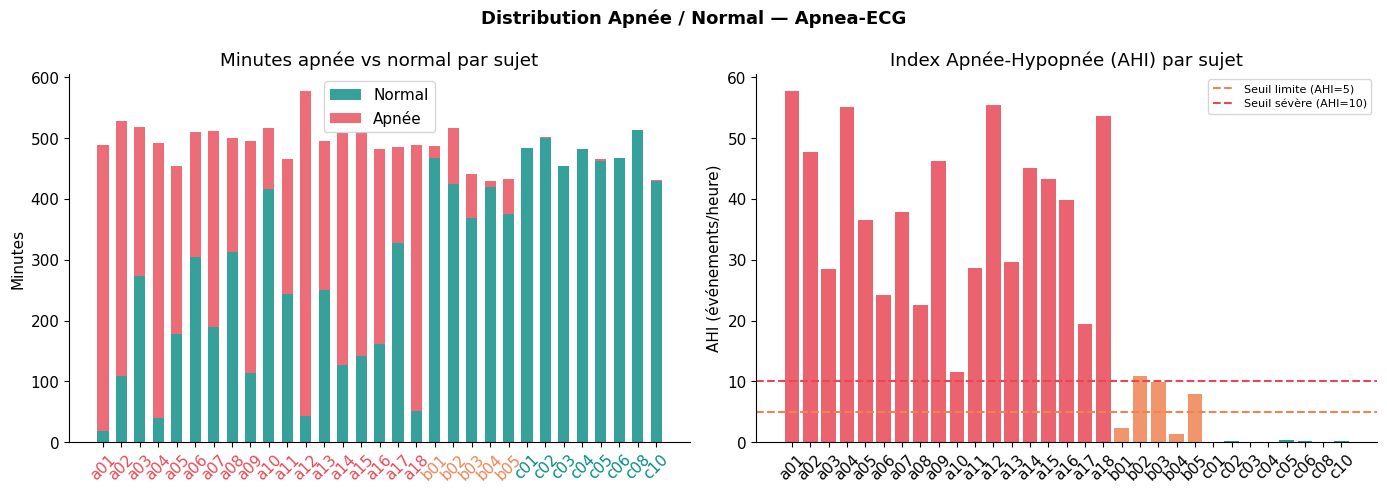

In [46]:
# Visualisation distribution par sujet
cat_colors = {'Sévère': '#E84855', 'Limite': '#EF8354', 'Normal': '#048A81'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution Apnée / Normal — Apnea-ECG', fontsize=13, fontweight='bold')

# Barplot empilé par sujet
x     = np.arange(len(df_apnea))
width = 0.6
bars1 = axes[0].bar(x, df_apnea['Minutes normal'],  width, label='Normal',
                     color='#048A81', alpha=0.8)
bars2 = axes[0].bar(x, df_apnea['Minutes apnée'],   width,
                     bottom=df_apnea['Minutes normal'], label='Apnée',
                     color='#E84855', alpha=0.8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(df_apnea['Sujet'], rotation=45)
axes[0].set_ylabel('Minutes')
axes[0].set_title('Minutes apnée vs normal par sujet')
axes[0].legend()

# Couleur des labels selon catégorie
for tick, cat in zip(axes[0].get_xticklabels(), df_apnea['Catégorie']):
    tick.set_color(cat_colors[cat])

# AHI par sujet
colors_bar = [cat_colors[c] for c in df_apnea['Catégorie']]
axes[1].bar(df_apnea['Sujet'], df_apnea['AHI (events/h)'], color=colors_bar, alpha=0.85)
axes[1].axhline(5,  color='#EF8354', linestyle='--', linewidth=1.5, label='Seuil limite (AHI=5)')
axes[1].axhline(10, color='#E84855', linestyle='--', linewidth=1.5, label='Seuil sévère (AHI=10)')
axes[1].set_ylabel('AHI (événements/heure)')
axes[1].set_title('Index Apnée-Hypopnée (AHI) par sujet')
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/figures/apnea_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### B4. Analyse fréquentielle ECG : Apnée vs Normal

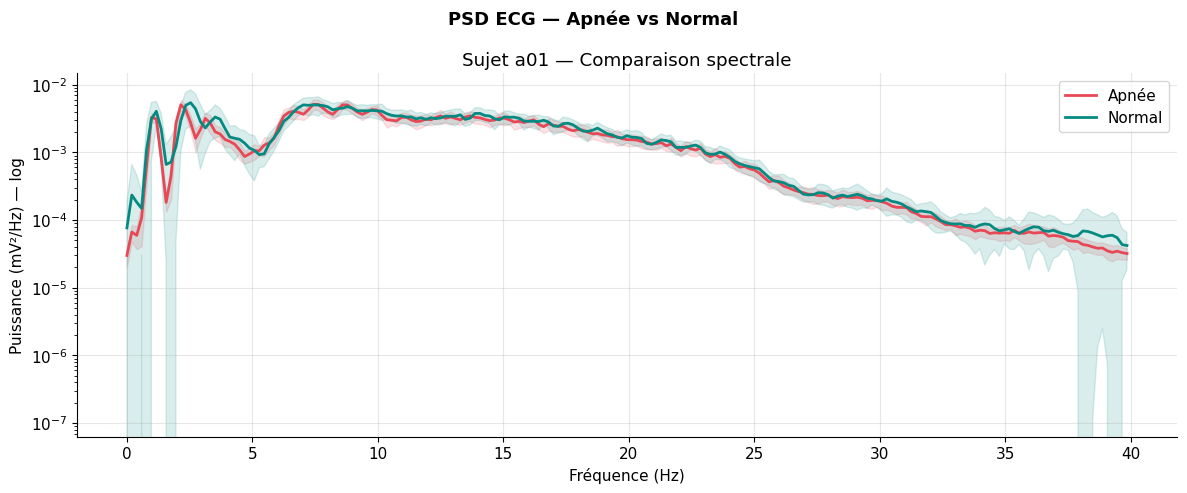


 Segments analysés :
   Apnée  : 20 segments d'1 min
   Normal : 19 segments d'1 min


In [47]:
# Comparer la PSD ECG en apnée vs normal
def get_ecg_segments_by_label(subj, label='A', n_segments=20):
    """Extrait des segments ECG d'1 minute par label (A/N)."""
    rec = wfdb.rdrecord(str(DATA_RAW_ECG / subj))
    ann = wfdb.rdann(str(DATA_RAW_ECG / subj), 'apn')
    ecg = rec.p_signal[:, 0]
    fs  = rec.fs
    seg_len = 60 * fs
    
    segments = []
    for i, sym in enumerate(ann.symbol):
        if sym == label and len(segments) < n_segments:
            start = i * seg_len
            end   = start + seg_len
            if end <= len(ecg):
                segments.append(ecg[start:end])
    return segments, fs

segs_apnea,  fs_ecg = get_ecg_segments_by_label(subjects[0], 'A')
segs_normal, _      = get_ecg_segments_by_label(subjects[0], 'N')

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('PSD ECG — Apnée vs Normal', fontsize=13, fontweight='bold')

for segs, label, color in [
    (segs_apnea,  'Apnée',  '#E84855'),
    (segs_normal, 'Normal', '#048A81'),
]:
    if not segs:
        continue
    psds = [welch(s, fs=fs_ecg, nperseg=512)[1] for s in segs]
    freqs = welch(segs[0], fs=fs_ecg, nperseg=512)[0]
    psd_mean = np.mean(psds, axis=0)
    psd_std  = np.std(psds, axis=0)
    mask = freqs <= 40
    ax.semilogy(freqs[mask], psd_mean[mask], color=color, label=label, linewidth=2)
    ax.fill_between(freqs[mask],
                     psd_mean[mask] - psd_std[mask],
                     psd_mean[mask] + psd_std[mask],
                     color=color, alpha=0.15)

ax.set_xlabel('Fréquence (Hz)')
ax.set_ylabel('Puissance (mV²/Hz) — log')
ax.set_title(f'Sujet {subjects[0]} — Comparaison spectrale')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/figures/ecg_spectral_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n Segments analysés :')
print(f'   Apnée  : {len(segs_apnea)} segments d\'1 min')
print(f'   Normal : {len(segs_normal)} segments d\'1 min')

---
## Synthèse de l'exploration

In [48]:
print('=' * 60)
print('SYNTHÈSE — EXPLORATION DES DONNÉES')
print('=' * 60)

print('\n📌 PARTIE A — Sleep-EDF (Stades de sommeil)')
print(f'   Sujets disponibles  : {len(psg_files)}')
print(f'   Total époques (30s) : {len(all_stages):,}')
print(f'   Déséquilibre classes: Wake et N2 surreprésentés → SMOTE nécessaire')
print(f'   Signal EEG          : 100 Hz, canal Fpz-Cz principal')
print(f'   Features identifiées: Delta↑ pour N3, Theta↑ pour N1, ressemblance REM/Wake')

print('\n📌 PARTIE B — Apnea-ECG (Détection apnées)')
print(f'   Sujets disponibles  : {len(subjects)}')
print(f'   Total minutes apnée : {df_apnea["Minutes apnée"].sum()}')
print(f'   Total minutes normal: {df_apnea["Minutes normal"].sum()}')
pct_apnea = df_apnea['Minutes apnée'].sum() / df_apnea['Total minutes'].sum() * 100
print(f'   % global apnée      : {pct_apnea:.1f}%')
print(f'   Signal ECG          : 100 Hz, 1 dérivation')
print(f'   Features à extraire : intervalle RR, variabilité HRV, amplitude QRS')

print('\n🔜 PROCHAINE ÉTAPE : Notebook 02 — Preprocessing')
print('   → Extraction features EEG (16 features temporelles + spectrales)')
print('   → Extraction features ECG (RR intervals + HRV + statistiques)')
print('   → Sauvegarde X_train/val/test .npy pour les deux tâches')

SYNTHÈSE — EXPLORATION DES DONNÉES

📌 PARTIE A — Sleep-EDF (Stades de sommeil)
   Sujets disponibles  : 30
   Total époques (30s) : 76,447
   Déséquilibre classes: Wake et N2 surreprésentés → SMOTE nécessaire
   Signal EEG          : 100 Hz, canal Fpz-Cz principal
   Features identifiées: Delta↑ pour N3, Theta↑ pour N1, ressemblance REM/Wake

📌 PARTIE B — Apnea-ECG (Détection apnées)
   Sujets disponibles  : 31
   Total minutes apnée : 5988
   Total minutes normal: 9148
   % global apnée      : 39.6%
   Signal ECG          : 100 Hz, 1 dérivation
   Features à extraire : intervalle RR, variabilité HRV, amplitude QRS

🔜 PROCHAINE ÉTAPE : Notebook 02 — Preprocessing
   → Extraction features EEG (16 features temporelles + spectrales)
   → Extraction features ECG (RR intervals + HRV + statistiques)
   → Sauvegarde X_train/val/test .npy pour les deux tâches
